# 4.3 · OWL in context

OWL lives in the **Semantic Web** stack and can be linked to more expressive logics (Common Logic, DOL).

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))  # repo paths
sys.path.insert(0, '.')
import matplotlib; matplotlib.use('Agg')
import ch4_toolkit as ch4
import owlready2, rdflib, owlrl, pandas as pd
print('owlready2', owlready2.VERSION, '| rdflib', rdflib.__version__, '| toolkit ready')

owlready2 0.50 | rdflib 7.6.0 | toolkit ready


## 4.3.1 OWL and the Semantic Web — the 'layer cake' (Figure 4.4)

In [2]:
for name, desc in ch4.SEMANTIC_WEB_LAYERS:
    print(f'{name:30s} {desc}')

URI / Unicode                  Identification & characters
XML                            Surface syntax (no semantics)
RDF                            Data model: relations between things
RDFS / SHACL                   Schema / shapes & constraints
SPARQL / RIF / SWRL / R2RML    Query, rules, RDB-to-RDF
OWL                            Ontology language: knowledge & reasoning
Applications                   User-facing systems


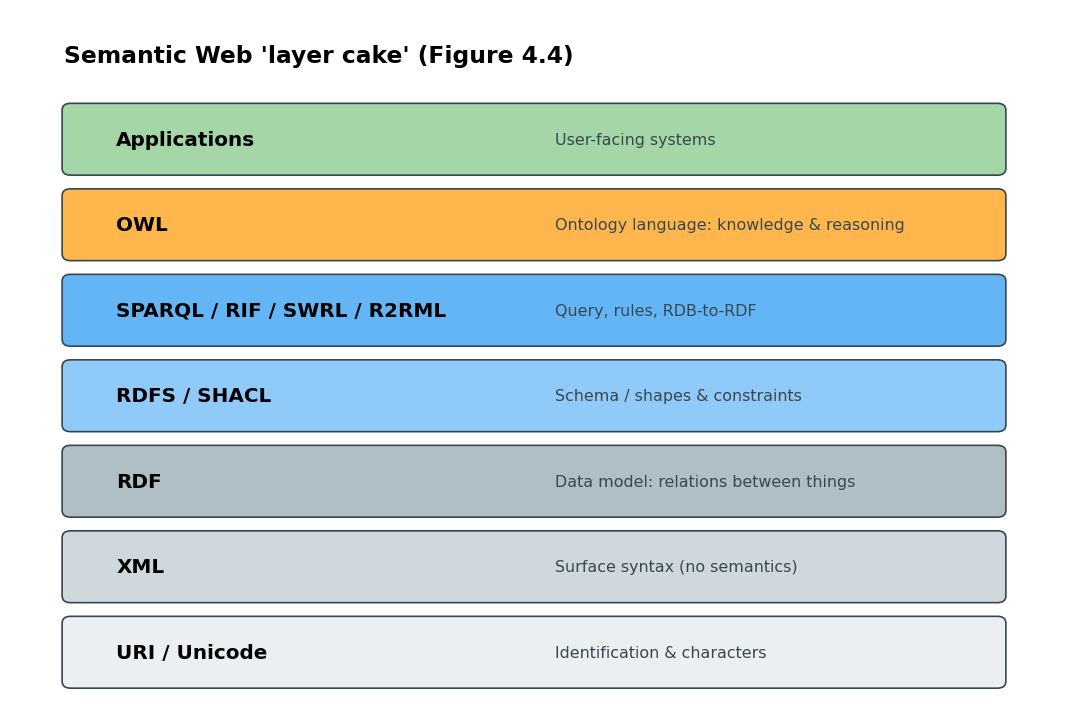

In [3]:
from IPython.display import Image
p = ch4.draw_semantic_web_layercake('artifacts/semantic_web_layercake.png')
Image(filename=p)

### SPARQL — querying RDF (the 'SQL of the Semantic Web')
We can serialise our ontology to RDF and query it. Below: list classes and the `eats` restrictions in the AWO.

In [4]:
awo = ch4.build_awo(1)
g = awo.world.as_rdflib_graph()
q = '''
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX owl: <http://www.w3.org/2002/07/owl#>
SELECT ?cls WHERE { ?cls a owl:Class . FILTER(isIRI(?cls)) } ORDER BY ?cls'''
for row in list(g.query(q))[:12]:
    print('  class:', str(row.cls).split('#')[-1])

  class: Animal
  class: Branch
  class: Carnivore
  class: Giraffe
  class: Herbivore
  class: Impala
  class: Leaf
  class: Lion
  class: Omnivore
  class: Plant
  class: PlantPart
  class: Plant_with_parts


### Reasoning + query together
Materialise the OWL 2 RL closure, then query the **inferred** subclass hierarchy.

In [5]:
g, b, a, new = ch4.reason_owlrl(awo)
from rdflib import RDFS
q = '''PREFIX rdfs:<http://www.w3.org/2000/01/rdf-schema#>
SELECT ?s ?o WHERE { ?s rdfs:subClassOf ?o . FILTER(isIRI(?s) && isIRI(?o)) }'''
pairs = sorted({(str(r.s).split('#')[-1], str(r.o).split('#')[-1]) for r in g.query(q)})
for s, o in pairs[:15]:
    print(f'  {s} ⊑ {o}')

  Animal ⊑ Animal
  Animal ⊑ Thing
  Branch ⊑ Branch
  Branch ⊑ PlantPart
  Branch ⊑ Thing
  Carnivore ⊑ Animal
  Carnivore ⊑ Carnivore
  Carnivore ⊑ Thing
  Giraffe ⊑ Animal
  Giraffe ⊑ Giraffe
  Giraffe ⊑ Herbivore
  Giraffe ⊑ Thing
  Herbivore ⊑ Animal
  Herbivore ⊑ Herbivore
  Herbivore ⊑ Thing


## 4.3.2 Common Logic (CL)
An ISO-standardised FOL family; the Semantic Web languages map *into* CL.

In [6]:
cl = ch4.COMMON_LOGIC
print(cl['name']); print(cl['family'])
print('dialects:'); [print('  -', d) for d in cl['dialects']]
print('design goals:'); [print('  -', d) for d in cl['design_goals']]

Common Logic (CL), ISO-standardised
First-order logic family with a common abstract syntax, model-theoretic semantics, XML.
dialects:
  - CLIF (Common Logic Interchange Format, textual)
  - CGIF (Conceptual Graph Interchange Format, diagrams)
  - XCL (eXtended Common Logic Markup Language, XML)
design goals:
  - Common interlingua for varied KR notations
  - Syntactically as unconstrained as possible
  - Semantically as simple/conventional as possible
  - Full FOL with equality, at least
  - Web-savvy, up-to-date
  - Historical origins in KIF


[None, None, None, None, None, None]

## 4.3.3 DOL — Distributed Ontology, Model & Specification Language
A metalanguage to combine ontologies in different logics and reason over the combined theory (solves the Example 4.2 trade-off by linking modules).

In [7]:
dol = ch4.DOL
for k, v in dol.items():
    print(f'{k}: {v}')

name: Distributed Ontology, Model and Specification Language (DOL)
standard: OMG standard (2016)
idea: A unified metalanguage to combine ontologies in different logics; put axioms that violate OWL 2 DL restrictions in a linked module and reason over the combined theory.
theory: Uses institutions to tie logics together (interoperability across logics).
tools: ['Heterogeneous Tool Set (Hets)', 'OntoHub repository']
